# 01 — Data Pipeline & Descriptive Statistics

Load cached market data, compute descriptive statistics, and export baseline CSVs.

**Securities Universe:** XOM, CVX, COP, OXY, LNG, VG, FRO, STNG, ET, BIL  
**Date Range:** 2019-01-02 → 2026-04-02  
**Data Source:** Yahoo Finance (equities), FRED (macro/commodities)

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(os.path.join('..', '..')))

import pickle
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.colors import LinearSegmentedColormap
from scipy.stats import norm, skew, kurtosis

from energy_workbook.config import (
    ALL_TICKERS, EQUITY_TICKERS, FUNDAMENTALS, RF_RATE,
    REGIME_NAMES, PAIRS, EVENT_WINDOWS, EWMA_LAMBDA,
    OIL_PRICE_PATH, SCENARIO_NAMES, SCENARIO_PROBS,
    SCENARIO_INPUTS, SCENARIO_HORIZON_DAYS,
)

# Paths
VIZ = os.path.abspath(os.path.join('..', 'visualization'))
DATA = os.path.abspath(os.path.join('..', 'data'))
os.makedirs(VIZ, exist_ok=True)
os.makedirs(DATA, exist_ok=True)

# Style
plt.rcParams.update({
    'font.family': 'serif', 'font.serif': ['Georgia', 'Times New Roman'],
    'font.size': 11, 'axes.labelsize': 12, 'axes.titlesize': 14,
    'figure.facecolor': 'white', 'axes.facecolor': '#FAFAFA',
    'axes.edgecolor': '#CCCCCC', 'axes.grid': True,
    'grid.alpha': 0.3, 'grid.color': '#CCCCCC',
    'legend.fontsize': 9, 'legend.framealpha': 0.9,
})
MC_COLORS = ['#002B5C','#1A3C6E','#4A86C8','#0070C0','#C89600',
             '#E06C00','#C00000','#008000','#7030A0','#666666',
             '#336699','#993333','#339966']
cmap_rg = LinearSegmentedColormap.from_list('rg', ['#C00000','#FFFFFF','#006100'])

print('Imports OK')

Imports OK


## 1.1 Load Cached Data

In [2]:
cache_path = os.path.abspath(os.path.join('..', '..', 'data_cache.pkl'))
with open(cache_path, 'rb') as f:
    D = pickle.load(f)

MASTER = D['master']
LOG_RET = D['log_returns']
DIFFS = D['diffs']

print(f'Master shape: {MASTER.shape}')
print(f'Date range: {MASTER.index[0].date()} → {MASTER.index[-1].date()}')
print(f'Columns: {list(MASTER.columns)}')
MASTER.head()

Master shape: (1823, 37)
Date range: 2019-01-02 → 2026-04-02
Columns: ['XOM', 'CVX', 'COP', 'OXY', 'LNG', 'VG', 'FRO', 'STNG', 'ET', 'BIL', 'SPY', 'WTI', 'Brent', 'HenryHub', 'VIX', 'OVX', 'FedFunds', 'DGS2', 'DGS10', 'T10YIE', 'DXY', 'CPI', 'CPI_Energy', 'IndProd', 'UMich', 'Claims', 'TTF', 'Gold', 'MOVE', 'Brent_WTI_Spread', 'TTF_HH_Spread', 'Spread_2s10s', 'Event_ID', 'Event_Label', 'OVX_Stress', 'VIX_Stress', 'Conflict_Period']


,XOM,CVX,COP,OXY,LNG,VG,FRO,STNG,ET,BIL,...,Gold,MOVE,Brent_WTI_Spread,TTF_HH_Spread,Spread_2s10s,Event_ID,Event_Label,OVX_Stress,VIX_Stress,Conflict_Period
Date,,,,,,,,,,,,,,,,,,,,,
2019-01-02,50.001846,80.604240,49.396591,52.724876,57.531273,NaN,3.324904,15.901784,7.007424,75.928970,...,1281.000000,62.799999,7.75,19.225000,0.16,1,Pre-COVID,0,0,0
2019-01-03,49.234127,79.060463,48.461349,52.078568,57.598164,NaN,3.354380,16.411999,7.055022,75.953896,...,1291.800049,65.790001,6.31,19.534999,0.17,1,Pre-COVID,0,0,0
2019-01-04,51.049374,80.698898,49.684963,53.753857,59.012558,NaN,3.507657,17.007252,7.499264,75.962219,...,1282.699951,65.820000,7.88,20.130000,0.17,1,Pre-COVID,0,0,0
2019-01-07,51.314850,81.747513,49.466743,54.833874,59.767532,NaN,3.548923,17.347401,7.647347,75.962219,...,1286.800049,60.880001,8.83,18.790001,0.17,1,Pre-COVID,0,0,0
2019-01-08,51.687939,81.390694,50.129200,55.267578,61.516407,NaN,3.619665,17.347401,7.816583,75.962219,...,1283.199951,59.049999,7.33,19.200000,0.15,1,Pre-COVID,0,0,0


In [3]:
# Quick data quality check
print('Missing data (% NaN):')
missing = (MASTER.isna().sum() / len(MASTER) * 100).round(1)
print(missing[missing > 0].sort_values(ascending=False).to_string())
print(f'\nLog returns shape: {LOG_RET.shape}')
print(f'Diffs shape: {DIFFS.shape}')

Missing data (% NaN):
Claims              100.0
VG                   83.6
Brent_WTI_Spread      2.2
Brent                 1.6
DXY                   1.4
UMich                 1.2
IndProd               1.2
CPI_Energy            1.2
CPI                   1.2
HenryHub              0.8
TTF_HH_Spread         0.8
T10YIE                0.7
WTI                   0.7
DGS10                 0.7
DGS2                  0.7
MOVE                  0.7
Spread_2s10s          0.7
OVX                   0.1
VIX                   0.1
TTF                   0.1

Log returns shape: (1823, 13)
Diffs shape: (1823, 8)


## 1.2 Descriptive Statistics

In [4]:
desc_stats = {}
for t in ALL_TICKERS:
    r = LOG_RET.get(t, pd.Series(dtype=float)).dropna()
    if len(r) < 30:
        continue
    cum = np.exp(r.cumsum())
    dd = (cum - cum.cummax()) / cum.cummax()
    desc_stats[t] = dict(
        count=len(r),
        ann_mean=float(r.mean() * 252),
        ann_vol=float(r.std() * np.sqrt(252)),
        skew=float(r.skew()),
        kurt=float(r.kurtosis()),
        sharpe=float((r.mean()*252 - RF_RATE) / (r.std()*np.sqrt(252))) if r.std() > 0 else 0,
        max_dd=float(dd.min()),
    )

stats_df = pd.DataFrame(desc_stats).T
stats_df.index.name = 'Ticker'
stats_df.to_csv(os.path.join(DATA, 'descriptive_stats.csv'))

# Format for display
display_df = stats_df.copy()
for c in ['ann_mean','ann_vol','max_dd']:
    display_df[c] = (display_df[c] * 100).round(2).astype(str) + '%'
display_df['sharpe'] = display_df['sharpe'].round(3)
display_df['skew'] = display_df['skew'].round(3)
display_df['kurt'] = display_df['kurt'].round(3)
display_df

,count,ann_mean,ann_vol,skew,kurt,sharpe,max_dd
Ticker,,,,,,,
XOM,1822.0,16.15%,31.11%,-0.224,5.313,0.416,-60.35%
CVX,1822.0,12.5%,32.24%,-1.129,26.352,0.289,-55.77%
COP,1822.0,13.44%,40.69%,-0.658,16.167,0.252,-67.11%
OXY,1822.0,2.46%,57.99%,-4.013,94.331,-0.013,-85.85%
LNG,1822.0,21.94%,33.64%,-0.871,9.535,0.557,-57.47%
VG,298.0,-41.1%,92.45%,-1.855,13.183,-0.479,-72.2%
FRO,1822.0,33.18%,53.91%,0.122,4.454,0.556,-52.04%
STNG,1822.0,21.71%,55.53%,-0.050,5.041,0.334,-77.37%
ET,1822.0,13.74%,35.81%,-1.894,30.806,0.295,-68.52%


## 1.3 Price Time Series

In [5]:
# Event bands helper
EVENT_BANDS = {
    2: ('2020-02-20','2020-06-30','#FFD6D6','COVID'),
    4: ('2022-02-24','2022-12-31','#FFE6CC','Russia-Ukraine'),
    6: ('2025-06-01','2025-06-30','#FFF0CC','12-Day War'),
    7: ('2026-02-28','2026-04-30','#FFD6D6','Iran Conflict'),
}
def add_events(ax):
    for _, (s, e, c, _) in EVENT_BANDS.items():
        try:
            ax.axvspan(pd.Timestamp(s), pd.Timestamp(e), alpha=0.15, color=c, zorder=0)
        except:
            pass

def savefig(fig, name, dpi=180):
    fig.savefig(os.path.join(VIZ, name), dpi=dpi, bbox_inches='tight',
                facecolor='white', edgecolor='none')
    print(f'  saved {name}')

  saved 01_cumulative_returns.png


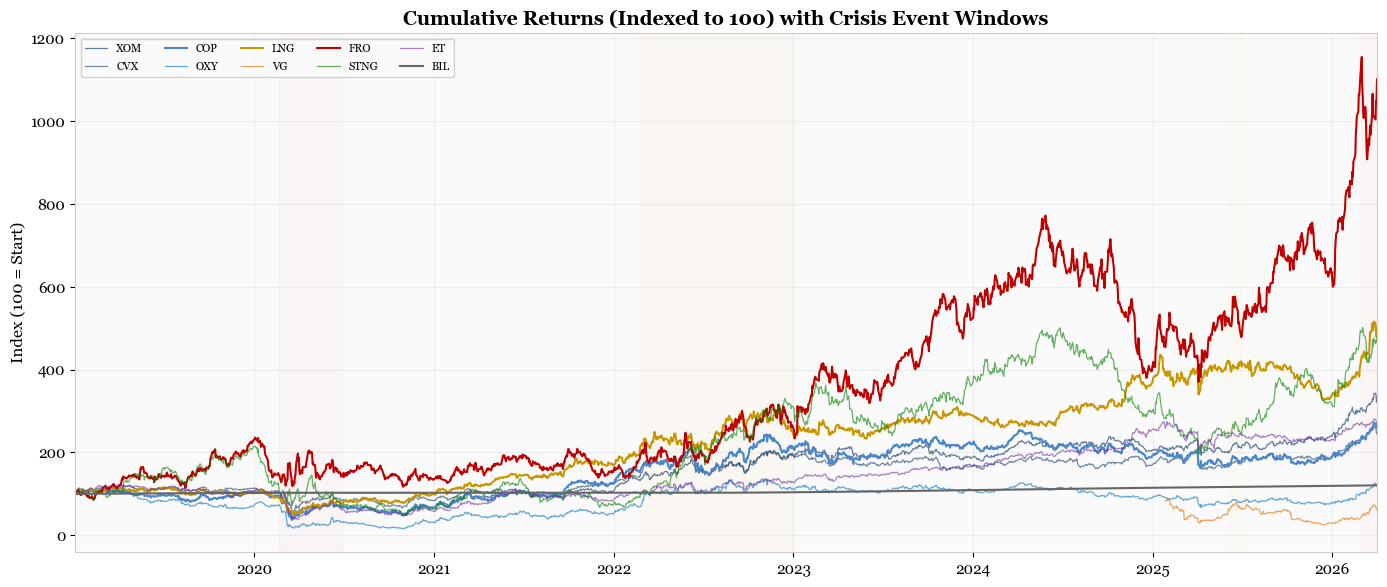

In [6]:
# Cumulative returns (indexed to 100)
fig, ax = plt.subplots(figsize=(14, 6))
for i, t in enumerate(ALL_TICKERS):
    r = LOG_RET.get(t, pd.Series(dtype=float)).dropna()
    if len(r) > 0:
        cum = np.exp(r.cumsum()) * 100
        ax.plot(cum.index, cum.values, label=t, color=MC_COLORS[i % len(MC_COLORS)],
                linewidth=1.5 if t in ['COP','FRO','LNG','BIL'] else 0.9,
                alpha=1.0 if t in ['COP','FRO','LNG','BIL'] else 0.6)
add_events(ax)
ax.set_title('Cumulative Returns (Indexed to 100) with Crisis Event Windows',
             fontweight='bold', fontsize=14)
ax.set_ylabel('Index (100 = Start)')
ax.legend(ncol=5, loc='upper left', fontsize=8)
ax.set_xlim(MASTER.index[0], MASTER.index[-1])
fig.tight_layout()
savefig(fig, '01_cumulative_returns.png')
plt.show()

## 1.4 Macro Dashboard

  saved 12_macro_dashboard.png


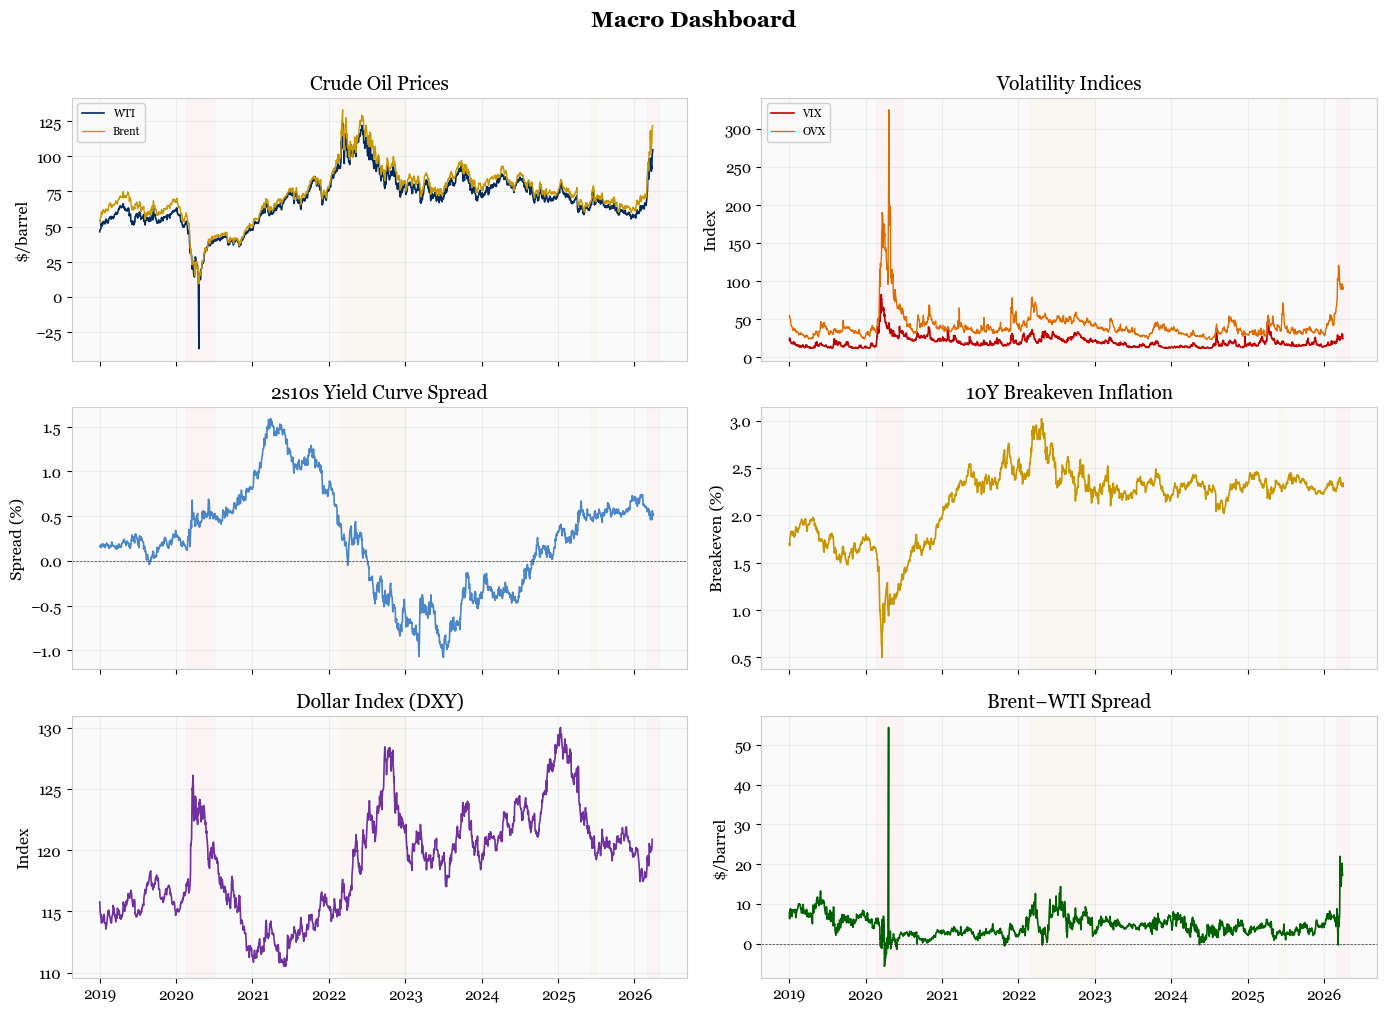

In [7]:
# Macro variables overview
vix = MASTER.get('VIX', pd.Series(dtype=float))
ovx = MASTER.get('OVX', pd.Series(dtype=float))
wti = MASTER.get('WTI', pd.Series(dtype=float))
brent = MASTER.get('Brent', pd.Series(dtype=float))
s2s10 = MASTER.get('Spread_2s10s', pd.Series(dtype=float))
bev = MASTER.get('T10YIE', pd.Series(dtype=float))
dxy = MASTER.get('DXY', pd.Series(dtype=float))

fig, axes = plt.subplots(3, 2, figsize=(14, 10), sharex=True)

# WTI & Brent
ax = axes[0,0]
ax.plot(wti.dropna().index, wti.dropna().values, label='WTI', color='#002B5C', linewidth=1.2)
ax.plot(brent.dropna().index, brent.dropna().values, label='Brent', color='#C89600', linewidth=1.0)
ax.set_ylabel('$/barrel'); ax.legend(fontsize=8); ax.set_title('Crude Oil Prices')
add_events(ax)

# VIX & OVX
ax = axes[0,1]
ax.plot(vix.dropna().index, vix.dropna().values, label='VIX', color='#C00000', linewidth=1.2)
ax.plot(ovx.dropna().index, ovx.dropna().values, label='OVX', color='#E06C00', linewidth=1.0)
ax.set_ylabel('Index'); ax.legend(fontsize=8); ax.set_title('Volatility Indices')
add_events(ax)

# 2s10s spread
ax = axes[1,0]
s2s10_clean = s2s10.dropna()
ax.plot(s2s10_clean.index, s2s10_clean.values, color='#4A86C8', linewidth=1.2)
ax.axhline(0, color='#333', linewidth=0.5, linestyle='--')
ax.set_ylabel('Spread (%)'); ax.set_title('2s10s Yield Curve Spread')
add_events(ax)

# Breakeven inflation
ax = axes[1,1]
bev_clean = bev.dropna()
ax.plot(bev_clean.index, bev_clean.values, color='#C89600', linewidth=1.2)
ax.set_ylabel('Breakeven (%)'); ax.set_title('10Y Breakeven Inflation')
add_events(ax)

# DXY
ax = axes[2,0]
dxy_clean = dxy.dropna()
ax.plot(dxy_clean.index, dxy_clean.values, color='#7030A0', linewidth=1.2)
ax.set_ylabel('Index'); ax.set_title('Dollar Index (DXY)')
add_events(ax)

# Brent-WTI spread
ax = axes[2,1]
bws = MASTER.get('Brent_WTI_Spread', pd.Series(dtype=float)).dropna()
if len(bws) > 0:
    ax.plot(bws.index, bws.values, color='#006100', linewidth=1.2)
    ax.axhline(0, color='#333', linewidth=0.5, linestyle='--')
ax.set_ylabel('$/barrel'); ax.set_title('Brent−WTI Spread')
add_events(ax)

fig.suptitle('Macro Dashboard', fontweight='bold', fontsize=16, y=1.01)
fig.tight_layout()
savefig(fig, '12_macro_dashboard.png')
plt.show()

## 1.5 Export Baseline Data

In [8]:
# Export core datasets
MASTER.to_csv(os.path.join(DATA, 'master_prices.csv'))
LOG_RET.to_csv(os.path.join(DATA, 'log_returns.csv'))
DIFFS.to_csv(os.path.join(DATA, 'macro_diffs.csv'))

print('Exported:')
print(f'  master_prices.csv  ({MASTER.shape})')
print(f'  log_returns.csv    ({LOG_RET.shape})')
print(f'  macro_diffs.csv    ({DIFFS.shape})')
print(f'  descriptive_stats.csv ({stats_df.shape})')

Exported:
  master_prices.csv  ((1823, 37))
  log_returns.csv    ((1823, 13))
  macro_diffs.csv    ((1823, 8))
  descriptive_stats.csv ((10, 7))


## 1.6 Security Profiles

In [9]:
# Fundamentals overview table
fund_data = {}
for t in ALL_TICKERS:
    f = FUNDAMENTALS.get(t, {})
    fund_data[t] = {
        'Name': f.get('name', ''),
        'Subsector': f.get('subsector', ''),
        'Mkt Cap ($B)': f'{f.get("mkt_cap",0)/1e9:.0f}' if f.get('mkt_cap') else 'N/A',
        'P/E': f.get('pe', 'N/A'),
        'EV/EBITDA': f.get('ev_ebitda', 'N/A'),
        'Div Yield': f'{f.get("div_yield",0)*100:.1f}%' if f.get('div_yield') is not None else 'N/A',
        'FCF Yield': f'{f.get("fcf_yield",0)*100:.1f}%' if f.get('fcf_yield') else 'N/A',
        'Production': f.get('production', 'N/A'),
    }
pd.DataFrame(fund_data).T

,Name,Subsector,Mkt Cap ($B),P/E,EV/EBITDA,Div Yield,FCF Yield,Production
XOM,Exxon Mobil,Integrated Major,460,14,9,3.5%,8.0%,3.7M boe/d
CVX,Chevron,Integrated Major,270,15,6.5,4.3%,7.0%,3.7M boe/d
COP,ConocoPhillips,Pure E&P,120,12,5,3.0%,9.0%,1.9M boe/d
OXY,Occidental Petroleum,E&P + Chemicals,35,14,4,2.0%,6.0%,1.48M boe/d
LNG,Cheniere Energy,LNG Export,50,10,10,1.0%,7.0%,9 trains
VG,Venture Global,LNG Export (Growth),21,39,8,0.0%,2.0%,128 cargos Q4
FRO,Frontline,Crude Tankers,3,7,6,10.0%,15.0%,41 VLCCs
STNG,Scorpio Tankers,Product Tankers,3,9,8,3.5%,10.0%,99 tankers
ET,Energy Transfer,Midstream Pipelines,65,11,7,7.0%,12.0%,130K+ miles
BIL,SPDR 1-3M T-Bill ETF,Ultrashort Treasury,43,None,None,3.2%,N/A,N/A


  saved 11_performance_analytics.png


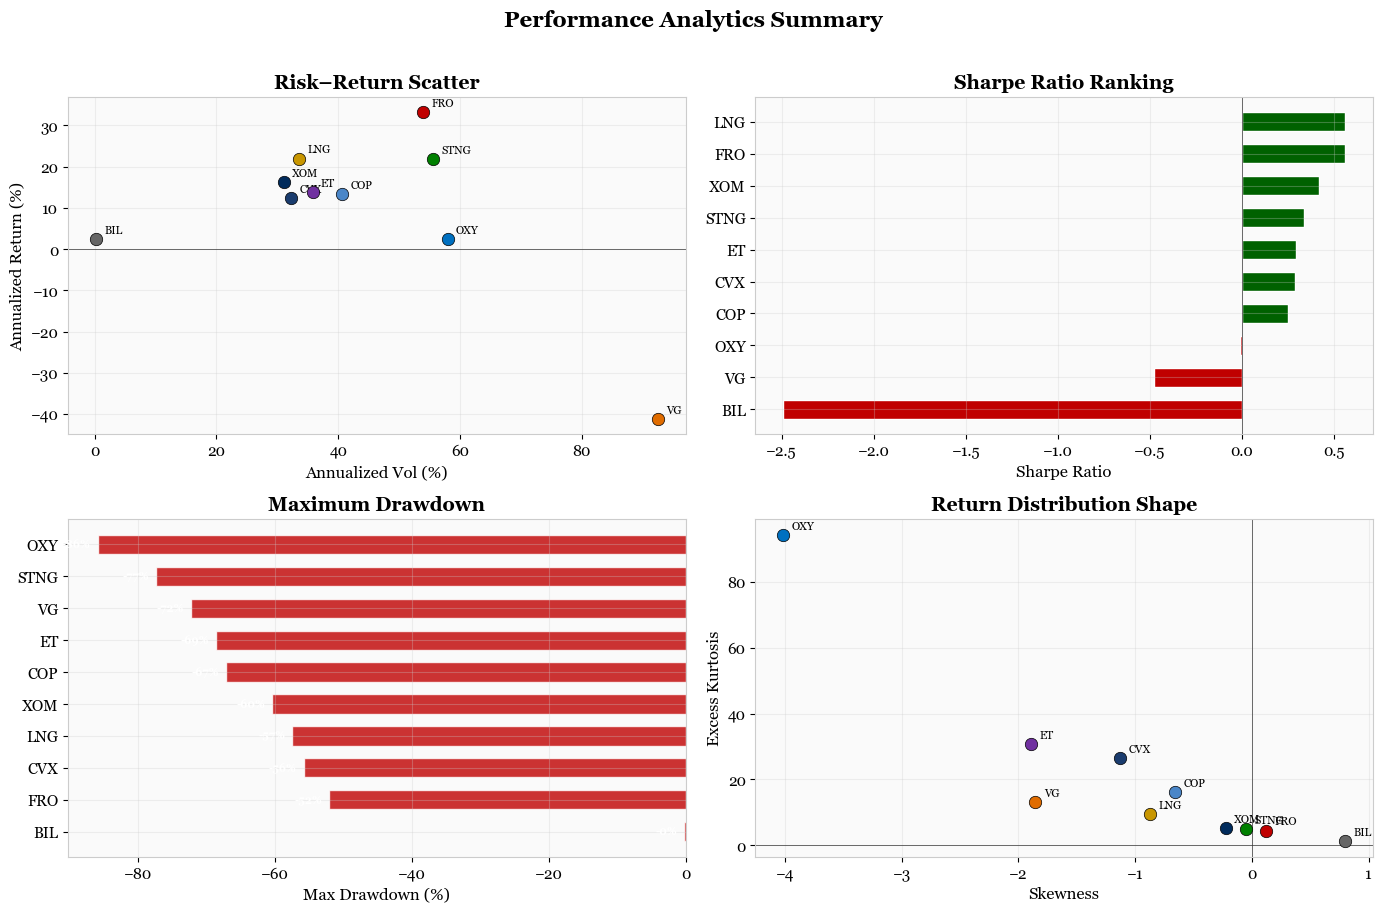

In [10]:
# Performance analytics chart
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# Annualized return vs vol scatter
ax = axes[0,0]
for i, t in enumerate(ALL_TICKERS):
    if t in desc_stats:
        s = desc_stats[t]
        ax.scatter(s['ann_vol']*100, s['ann_mean']*100, color=MC_COLORS[i%len(MC_COLORS)],
                   s=80, zorder=5, edgecolors='black', linewidth=0.5)
        ax.annotate(t, (s['ann_vol']*100, s['ann_mean']*100),
                    textcoords='offset points', xytext=(6,4), fontsize=8)
ax.set_xlabel('Annualized Vol (%)')
ax.set_ylabel('Annualized Return (%)')
ax.set_title('Risk–Return Scatter', fontweight='bold')
ax.axhline(0, color='#333', linewidth=0.5)

# Sharpe ranking
ax = axes[0,1]
sharpe_sorted = sorted(desc_stats.items(), key=lambda x: x[1]['sharpe'], reverse=True)
ts = [t for t,_ in sharpe_sorted]; sv = [s['sharpe'] for _,s in sharpe_sorted]
colors = ['#006100' if v>0 else '#C00000' for v in sv]
ax.barh(ts[::-1], sv[::-1], color=colors[::-1], edgecolor='white', height=0.6)
ax.set_xlabel('Sharpe Ratio'); ax.set_title('Sharpe Ratio Ranking', fontweight='bold')
ax.axvline(0, color='#333', linewidth=0.5)

# Max drawdown
ax = axes[1,0]
dd_sorted = sorted(desc_stats.items(), key=lambda x: x[1]['max_dd'])
ts = [t for t,_ in dd_sorted]; dv = [s['max_dd']*100 for _,s in dd_sorted]
ax.barh(ts[::-1], dv[::-1], color='#C00000', edgecolor='white', height=0.6, alpha=0.8)
for bar, val in zip(ax.patches, dv[::-1]):
    ax.text(bar.get_width()-1, bar.get_y()+bar.get_height()/2,
            f'{val:.0f}%', va='center', ha='right', fontsize=8, color='white', fontweight='bold')
ax.set_xlabel('Max Drawdown (%)')
ax.set_title('Maximum Drawdown', fontweight='bold')

# Skew vs Kurtosis
ax = axes[1,1]
for i, t in enumerate(ALL_TICKERS):
    if t in desc_stats:
        s = desc_stats[t]
        ax.scatter(s['skew'], s['kurt'], color=MC_COLORS[i%len(MC_COLORS)],
                   s=80, zorder=5, edgecolors='black', linewidth=0.5)
        ax.annotate(t, (s['skew'], s['kurt']),
                    textcoords='offset points', xytext=(6,4), fontsize=8)
ax.set_xlabel('Skewness'); ax.set_ylabel('Excess Kurtosis')
ax.set_title('Return Distribution Shape', fontweight='bold')
ax.axvline(0, color='#333', linewidth=0.5)
ax.axhline(0, color='#333', linewidth=0.5)

fig.suptitle('Performance Analytics Summary', fontweight='bold', fontsize=16, y=1.01)
fig.tight_layout()
savefig(fig, '11_performance_analytics.png')
plt.show()